In [4]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os

# 动态网络风险溢出指标时变图

## 总体关联性指数（未过滤网络）

In [5]:
import pandas as pd
import numpy as np


file_path = '../differenced_data/dynamic_spillover_matrices.csv' 
df_raw = pd.read_csv(file_path)
id_vars = ['FROM', 'Date', 'From', 'TO', 'End_Date'] # 根据您的实际列名调整
spillover_cols = [col for col in df_raw.columns if col not in id_vars and df_raw[col].dtype in ['float64', 'int64']]
N = len(spillover_cols)

# 存储 TCI 结果
tci_results = []
dates = []

for date, group in df_raw.groupby('Date'):
    
    # 提取溢出矩阵部分
    spillover_matrix_df = group[spillover_cols].reset_index(drop=True)
    if len(spillover_matrix_df) < N:
        spillover_matrix = spillover_matrix_df.head(N).values
    else:
        spillover_matrix = spillover_matrix_df.values


    sum_all = np.nansum(spillover_matrix)
    
    sum_diag = np.nansum(np.diag(spillover_matrix))
    sum_off_diag = sum_all - sum_diag
    
    # TCI 公式
    if sum_all != 0:
        tci = (sum_off_diag / sum_all) * 100
    else:
        tci = 0
        
    tci_results.append(tci)
    dates.append(pd.to_datetime(date))

# 6. 创建 TCI 时间序列 DataFrame
tci_df = pd.DataFrame({
    'Date': dates,
    'TCI': tci_results
}).sort_values('Date').reset_index(drop=True)

print("TCI 计算完成，前五行结果：")
print(tci_df.tail())

TCI 计算完成，前五行结果：
          Date        TCI
109 2025-04-14  97.349471
110 2025-05-28  97.140142
111 2025-07-10  97.062303
112 2025-08-20  97.162623
113 2025-09-30  97.344593


In [9]:
print(tci_df)

          Date        TCI
0   2012-03-15  90.342811
1   2012-04-27  96.325723
2   2012-06-12  96.429275
3   2012-07-25  96.618043
4   2012-09-03  96.827414
..         ...        ...
109 2025-04-14  97.349471
110 2025-05-28  97.140142
111 2025-07-10  97.062303
112 2025-08-20  97.162623
113 2025-09-30  97.344593

[114 rows x 2 columns]


In [6]:
start = '2012-03-15'
end = '2025-09-30'
trading_days = pd.bdate_range(start=start, end=end)
print(len(trading_days))

3534


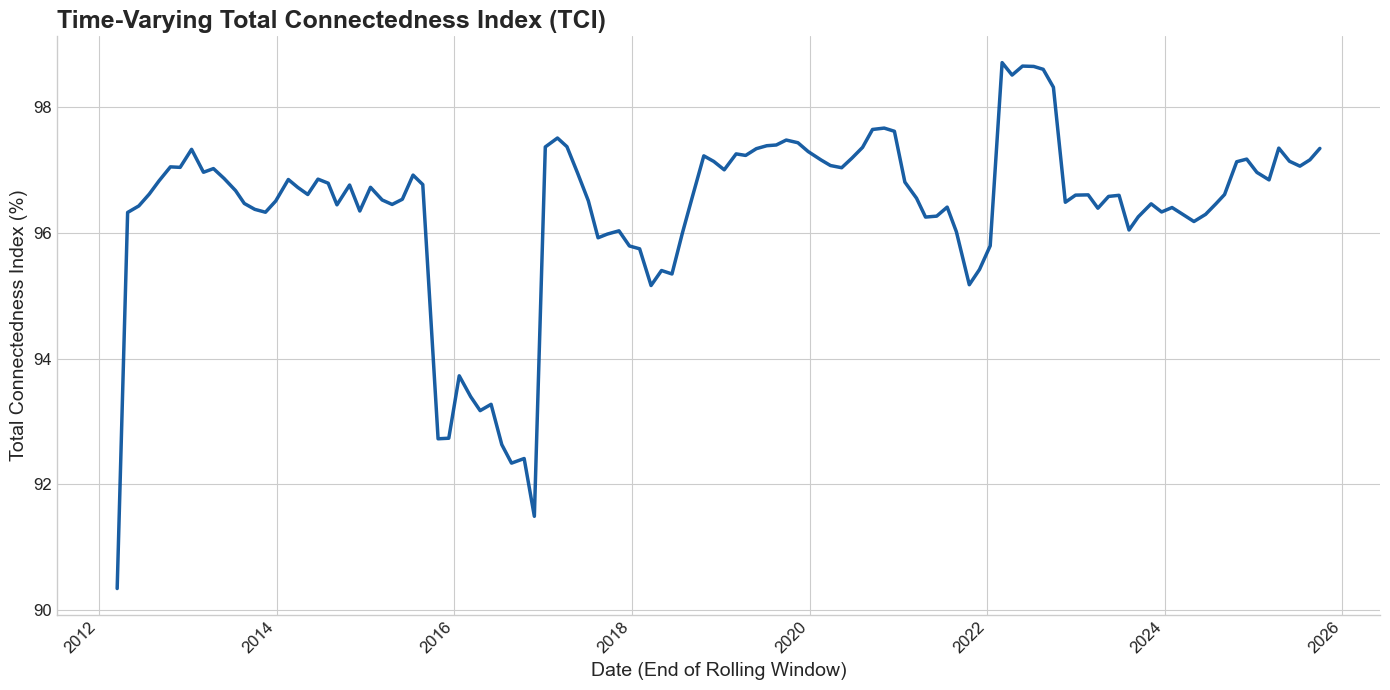

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 设置 Matplotlib/Seaborn 风格
# 使用 'ggplot' 或 'seaborn-v0_8-whitegrid' 等风格，增加专业感
plt.style.use('seaborn-v0_8-whitegrid') 

# 2. 绘制时变图
plt.figure(figsize=(14, 7)) # 略微增大图表尺寸
ax = plt.gca() # 获取当前轴

# 使用更柔和的颜色，并增加透明度
sns.lineplot(x='Date', y='TCI', data=tci_df, color='#004C99', linewidth=2.5, alpha=0.9, ax=ax)

# 3. 优化网格线和刻度
# 移除上边和右边的边框线，使图表更清晰
sns.despine(ax=ax, top=True, right=True)

# 增加水平辅助线（可选：中枢线或平均线）
# mean_tci = tci_df['TCI'].mean()
# ax.axhline(mean_tci, color='grey', linestyle='--', linewidth=1.0, alpha=0.7, label=f'Mean TCI ({mean_tci:.1f}%)')

# 4. 优化标题和标签 (全部使用英文)
ax.set_title(
    'Time-Varying Total Connectedness Index (TCI)', 
    fontsize=18, 
    fontweight='bold',
    loc='left' # 标题左对齐，更符合学术论文排版
)

ax.set_xlabel('Date (End of Rolling Window)', fontsize=14)
ax.set_ylabel('Total Connectedness Index (%)', fontsize=14)

# 5. 优化日期刻度
plt.xticks(rotation=45, ha='right', fontsize=12) # 旋转并右对齐日期标签
plt.yticks(fontsize=12)

# 6. 自动调整布局并显示
plt.tight_layout()

plt.show()

## 网络宏观特征指标（过滤网络）

### PMFG

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from itertools import combinations
import os

def get_top_edges(spillover_matrix_df, num_edges_to_keep=None):
    """
    根据溢出矩阵构建一个带权重的边列表，并按权重降序排列。
    """
    institutions = spillover_matrix_df.columns
    N = len(institutions)
    edges = []
    for i in range(N):
        for j in range(i + 1, N):
            source = institutions[i]
            target = institutions[j]
            weight = spillover_matrix_df.iloc[i, j] + spillover_matrix_df.iloc[j, i]
            edges.append((source, target, weight))

    # 按权重降序排序
    edges.sort(key=lambda x: x[2], reverse=True)

    if num_edges_to_keep is not None:
        return edges[:num_edges_to_keep]
    return edges

file_path = '../differenced_data/dynamic_spillover_matrices.csv'
try:
    df_raw = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"错误：未找到风险溢出矩阵文件 '{file_path}'。请检查路径。")
    exit()

# 识别日期列和机构列
if 'End_Date' in df_raw.columns:
    date_col = 'End_Date'
elif 'Date' in df_raw.columns:
    date_col = 'Date'
else:
    print("错误：数据中未找到时间索引列。")
    exit()

# 识别机构列 (溢出矩阵的元素)
# 排除非数字列（辅助列）
id_vars = [date_col, 'FROM', 'Date', 'From', 'TO', 'NET', 'Total'] 
institutions = [col for col in df_raw.columns if col not in id_vars and df_raw[col].dtype in ['float64', 'int64']]
N = len(institutions)

# PMFG 约束：保留的边数
# PMFG 过滤图有 N 个节点，最多可以有 3*(N-2) 条边
max_pmfg_edges = 3 * (N - 2)
if N < 3:
    max_pmfg_edges = 0 

print(f"检测到 {N} 个金融机构。PMFG 过滤最多保留 {max_pmfg_edges} 条边。")

# 存储所有动态网络的结果（边列表形式）
dynamic_pmfg_networks = {} 

# 2. 遍历时间窗口并应用 PMFG 过滤
for date, group in df_raw.groupby(date_col):
    
    # 提取溢出矩阵部分 (N x N)
    # 假设每个时间窗的溢出矩阵是前 N 行
    spillover_matrix_df = group[institutions].head(N).reset_index(drop=True)
    spillover_matrix_df.columns = institutions
    spillover_matrix_df.index = institutions
    
    # 3. 应用 PMFG 过滤
    all_edges_sorted = get_top_edges(spillover_matrix_df)
    
    # 理论上，真正的 PMFG 算法会确保图是平面图。这里我们进行简单的截断。
    pmfg_edges = all_edges_sorted[:max_pmfg_edges]
    
    # 4. 构建 NetworkX 图对象并存储
    G = nx.Graph()
    G.add_nodes_from(institutions)
    
    # 添加过滤后的边
    for u, v, w in pmfg_edges:
        G.add_edge(u, v, weight=w)
        
    dynamic_pmfg_networks[date] = G
    
    # 打印进度
    print(f"  > PMFG 网络构建完成：{date}，边数：{G.number_of_edges()}")

# 5. 结果存储与分析准备

print(f"\n动态 PMFG 网络构建完毕，共 {len(dynamic_pmfg_networks)} 个网络。")
print("下一步：基于这些网络计算时变拓扑指标。")

检测到 45 个金融机构。PMFG 过滤最多保留 129 条边。
  > PMFG 网络构建完成：2012/10/20，边数：129
  > PMFG 网络构建完成：2012/11/29，边数：129
  > PMFG 网络构建完成：2012/3/15，边数：129
  > PMFG 网络构建完成：2012/4/27，边数：129
  > PMFG 网络构建完成：2012/6/12，边数：129
  > PMFG 网络构建完成：2012/7/25，边数：129
  > PMFG 网络构建完成：2012/9/3，边数：129
  > PMFG 网络构建完成：2013/1/15，边数：129
  > PMFG 网络构建完成：2013/10/2，边数：129
  > PMFG 网络构建完成：2013/11/15，边数：129
  > PMFG 网络构建完成：2013/12/27，边数：129
  > PMFG 网络构建完成：2013/3/5，边数：129
  > PMFG 网络构建完成：2013/4/15，边数：129
  > PMFG 网络构建完成：2013/5/29，边数：129
  > PMFG 网络构建完成：2013/7/15，边数：129
  > PMFG 网络构建完成：2013/8/20，边数：129
  > PMFG 网络构建完成：2014/10/27，边数：129
  > PMFG 网络构建完成：2014/12/8，边数：129
  > PMFG 网络构建完成：2014/2/17，边数：129
  > PMFG 网络构建完成：2014/3/28，边数：129
  > PMFG 网络构建完成：2014/5/8，边数：129
  > PMFG 网络构建完成：2014/6/19，边数：129
  > PMFG 网络构建完成：2014/7/31，边数：129
  > PMFG 网络构建完成：2014/9/5，边数：129
  > PMFG 网络构建完成：2015/1/21，边数：129
  > PMFG 网络构建完成：2015/10/26，边数：129
  > PMFG 网络构建完成：2015/12/9，边数：129
  > PMFG 网络构建完成：2015/3/10，边数：129
  > PMFG 网络构建完成：2015/4/20，边数：129
  > PMFG

In [2]:
import pandas as pd
import numpy as np

file_path = '../differenced_data/dynamic_spillover_matrices.csv'
df_raw = pd.read_csv(file_path)
# 识别日期列和机构列 (假设 N 是机构数量)
date_col = 'End_Date' if 'End_Date' in df_raw.columns else 'Date'
id_vars = [date_col, 'FROM', 'Date', 'From', 'TO', 'NET', 'Total'] 
institutions = [col for col in df_raw.columns if col not in id_vars and df_raw[col].dtype in ['float64', 'int64']]
N = len(institutions)
# ----------------------------------------------------------

net_connectedness_records = []

# 遍历时间窗口
for date, group in df_raw.groupby(date_col):
    
    # 提取溢出矩阵部分 (N x N)
    spillover_matrix_df = group[institutions].head(N).reset_index(drop=True)
    spillover_matrix = spillover_matrix_df.values
    
    # 1. 计算 Out-Spillover (行和 - 对角线)
    # 风险从 i 溢出到 j (S_ij, j!=i)
    out_spillovers = np.nansum(spillover_matrix, axis=1) - np.diag(spillover_matrix)

    # 2. 计算 In-Spillover (列和 - 对角线)
    # 风险从 j 溢入到 i (S_ji, j!=i)
    in_spillovers = np.nansum(spillover_matrix, axis=0) - np.diag(spillover_matrix)

    # 3. 计算 Net Spillover
    net_spillovers = out_spillovers - in_spillovers
    
    # 4. 存储结果
    record = {'Date': pd.to_datetime(date)}
    for i, inst in enumerate(institutions):
        record[inst] = net_spillovers[i]
        
    net_connectedness_records.append(record)

# 构建最终的 NDC 时间序列 DataFrame
ndc_df = pd.DataFrame(net_connectedness_records).sort_values('Date').reset_index(drop=True)

print("净方向关联性指数 (NDC) 计算完成，前五行：")
print(ndc_df.head())

净方向关联性指数 (NDC) 计算完成，前五行：
        Date     CMB    CSC     ECP    DFC     XYR    HCX     NJB     GYS  \
0 2012-03-15  -15.87  47.82    1.62  26.60  -22.23  23.48   -4.13  -49.32   
1 2012-04-27 -149.11  25.00  -81.78  -7.73 -111.41 -27.77 -107.37 -182.94   
2 2012-06-12 -160.18  33.92  -68.24 -32.52 -105.61 -26.97 -121.84 -161.20   
3 2012-07-25 -155.29  24.22 -100.55  -3.46  -94.98 -39.06 -105.19 -171.20   
4 2012-09-03 -148.21  30.51 -108.45  -1.69 -113.68 -37.36 -109.35 -142.21   

      SXZ  ...     MWC    HJC     HXB    JLG     DBS    CMBC    XGD     GIC  \
0  -52.12  ...  -13.23   1.65    6.08  26.37  -41.64  -21.21  22.87   -3.79   
1 -172.95  ...  -90.96 -82.09  -79.64 -18.84 -167.74  -97.76   8.07  -92.88   
2 -152.19  ... -124.44 -87.82 -104.31 -23.47 -153.21 -101.85   6.38 -102.89   
3 -142.96  ... -129.51 -99.77  -88.65  -7.21 -121.05 -103.15  -2.32  -59.84   
4 -131.75  ... -113.53 -90.90  -91.06 -15.10 -127.57  -97.61  -7.30  -24.49   

     BJB     TPAC  
0 -11.24   -49.34

In [12]:
import pandas as pd
import networkx as nx

# 假设 G 是某时间窗口的 PMFG 网络
degrees = dict(G.degree(weight='weight'))
betweenness = nx.betweenness_centrality(G, weight='weight')

# 转 DataFrame
df_nodes = pd.DataFrame({
    'Institution': list(G.nodes),
    'Weighted_Degree': [degrees[n] for n in G.nodes],
    'Betweenness': [betweenness[n] for n in G.nodes]
})

# 标准化并计算综合评分
df_nodes['Weighted_Degree_norm'] = df_nodes['Weighted_Degree'] / df_nodes['Weighted_Degree'].max()
df_nodes['Betweenness_norm'] = df_nodes['Betweenness'] / df_nodes['Betweenness'].max()
df_nodes['Score'] = 0.5 * df_nodes['Weighted_Degree_norm'] + 0.5 * df_nodes['Betweenness_norm']

# 选取前10关键机构
key_institutions = df_nodes.sort_values('Score', ascending=False).head(10)
print(key_institutions)


   Institution  Weighted_Degree  Betweenness  Weighted_Degree_norm  \
44        TPAC           399.21          0.0              1.000000   
4          XYR           131.85          0.0              0.330277   
34         GHS            18.37          0.0              0.046016   
9          XLF            18.31          0.0              0.045866   
21      CITICS            17.06          0.0              0.042734   
18        SGXA            13.33          0.0              0.033391   
30         AJG            12.26          0.0              0.030711   
26         PAB            11.92          0.0              0.029859   
11         YTG            11.77          0.0              0.029483   
33         GJS            10.80          0.0              0.027053   

    Betweenness_norm     Score  
44               0.0  0.500000  
4                0.0  0.165139  
34               0.0  0.023008  
9                0.0  0.022933  
21               0.0  0.021367  
18               0.0  0.016695 

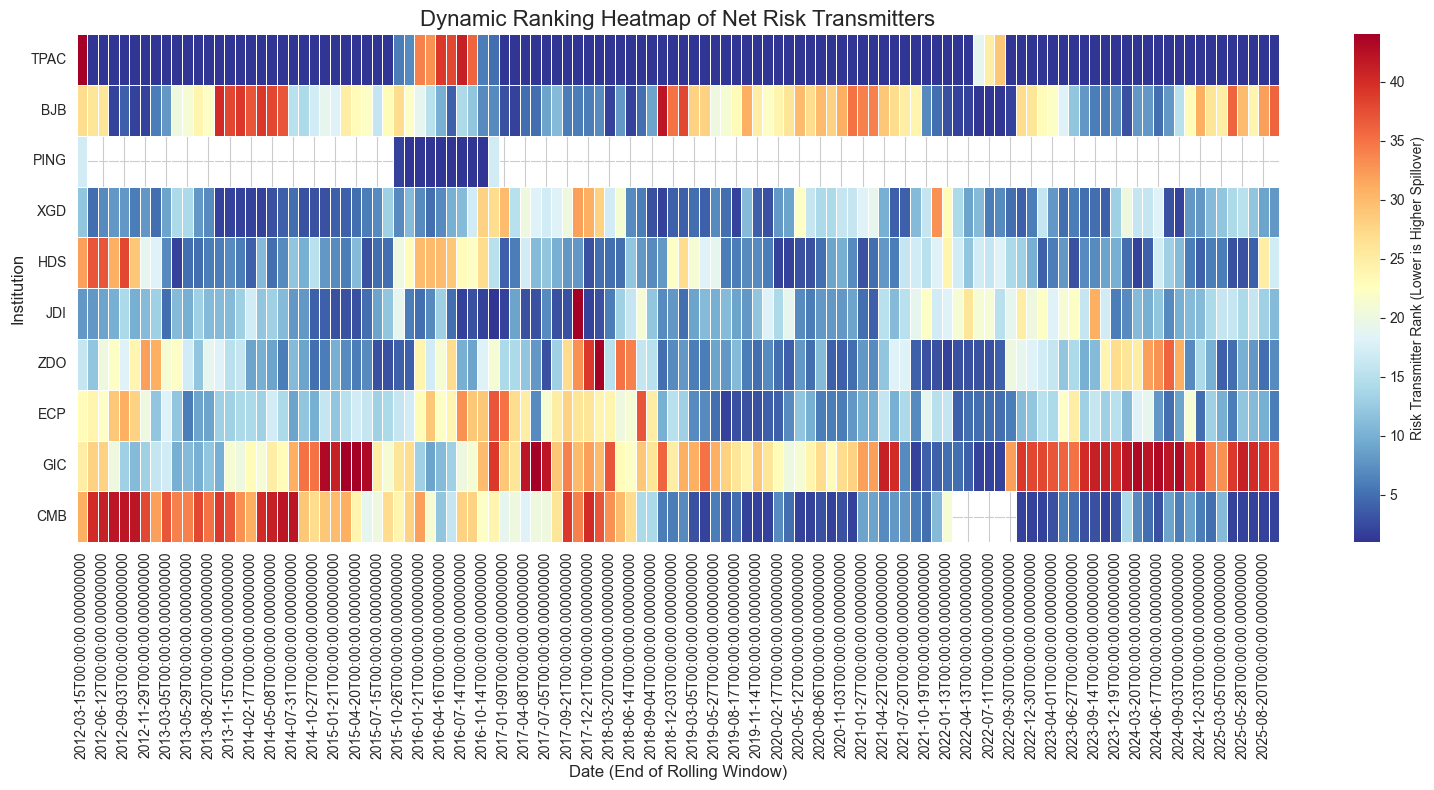

In [7]:
# 1. 计算每个时间点的 NDC 排名
rank_df = ndc_df.set_index('Date').rank(axis=1, ascending=False, method='min')

# 2. 选取排名前 N 的机构（防止图表过于拥挤）
top_institutions = ndc_df.set_index('Date').mean().nlargest(10).index.tolist()
rank_matrix = rank_df[top_institutions].T # 转置，让机构在 Y 轴，时间在 X 轴

plt.figure(figsize=(16, 8))
sns.heatmap(
    rank_matrix,
    cmap="RdYlBu_r", # 使用红黄蓝渐变色
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Risk Transmitter Rank (Lower is Higher Spillover)'}
)

plt.title('Dynamic Ranking Heatmap of Net Risk Transmitters', fontsize=16)
plt.xlabel('Date (End of Rolling Window)', fontsize=12)
plt.ylabel('Institution', fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [31]:
# 定义保存文件夹
output_folder = '../result/output_edgelists/'  # 替换为你的目标文件夹
os.makedirs(output_folder, exist_ok=True)  # 如果文件夹不存在，创建它

# 保存 PMFG 网络为 Edgelist 格式
for idx, pmfg in enumerate(pmfg_networks):
    output_file = os.path.join(output_folder, f'pmfg_network_{idx + 1}.edgelist')  # 拼接完整路径
    nx.write_edgelist(pmfg, output_file, data=['weight'])  # 保存边的权重
    print(f"PMFG 网络 {idx + 1} 已保存为 {output_file}")


PMFG 网络 1 已保存为 ../result/output_edgelists/pmfg_network_1.edgelist
PMFG 网络 2 已保存为 ../result/output_edgelists/pmfg_network_2.edgelist
PMFG 网络 3 已保存为 ../result/output_edgelists/pmfg_network_3.edgelist
PMFG 网络 4 已保存为 ../result/output_edgelists/pmfg_network_4.edgelist
PMFG 网络 5 已保存为 ../result/output_edgelists/pmfg_network_5.edgelist
PMFG 网络 6 已保存为 ../result/output_edgelists/pmfg_network_6.edgelist
PMFG 网络 7 已保存为 ../result/output_edgelists/pmfg_network_7.edgelist
PMFG 网络 8 已保存为 ../result/output_edgelists/pmfg_network_8.edgelist
PMFG 网络 9 已保存为 ../result/output_edgelists/pmfg_network_9.edgelist
PMFG 网络 10 已保存为 ../result/output_edgelists/pmfg_network_10.edgelist
PMFG 网络 11 已保存为 ../result/output_edgelists/pmfg_network_11.edgelist
PMFG 网络 12 已保存为 ../result/output_edgelists/pmfg_network_12.edgelist
PMFG 网络 13 已保存为 ../result/output_edgelists/pmfg_network_13.edgelist
PMFG 网络 14 已保存为 ../result/output_edgelists/pmfg_network_14.edgelist
PMFG 网络 15 已保存为 ../result/output_edgelists/pmfg_network_15.edgelis

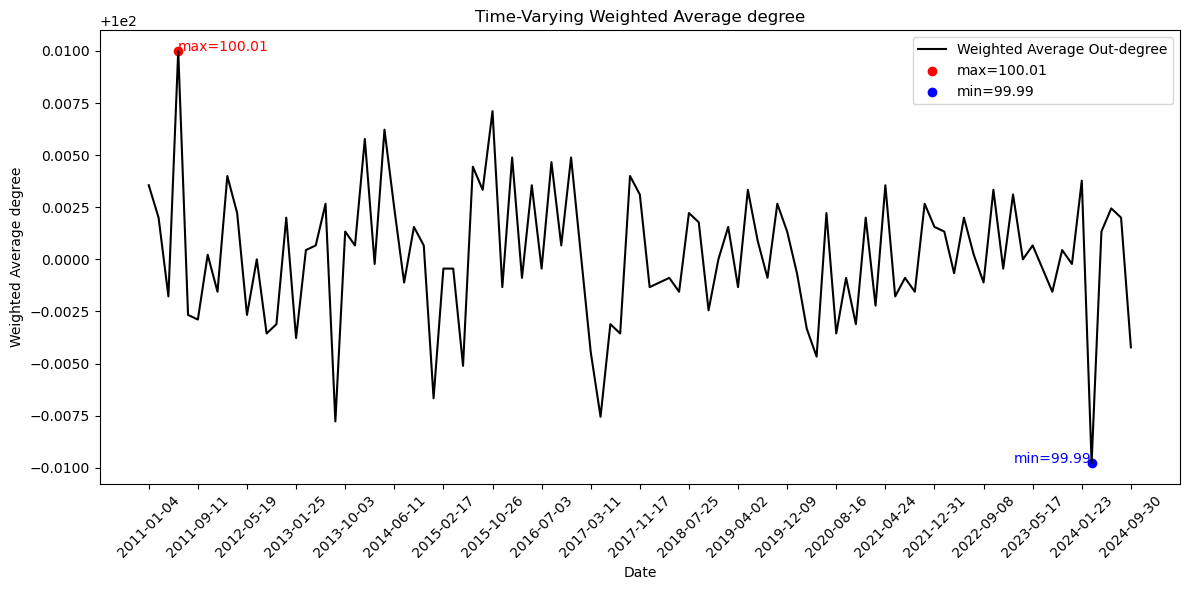

In [68]:
# 基本参数设置
num_nodes = 45  # 网络节点数
num_matrices = data.shape[0] // num_nodes  # 矩阵数量

# 时间范围
time_range = pd.date_range(start="2011-01-04", end="2024-09-30", periods=num_matrices)

# 初始化存储加权平均出度的列表
avg_out_degrees = []

# 逐个时间窗口计算加权平均出度
for i in range(num_matrices):
    # 提取当前矩阵
    start_row = i * num_nodes
    end_row = (i + 1) * num_nodes
    matrix = data.iloc[start_row:end_row].to_numpy()

    # 计算加权出度
    out_degrees = np.sum(matrix, axis=1)  # 按行求和，出度
    avg_out_degree = np.mean(out_degrees)  # 加权平均出度
    avg_out_degrees.append(avg_out_degree)

# 找到最大值和最小值
max_value = max(avg_out_degrees)
min_value = min(avg_out_degrees)
max_index = avg_out_degrees.index(max_value)
min_index = avg_out_degrees.index(min_value)

# 绘制图表
plt.figure(figsize=(12, 6))
plt.plot(time_range, avg_out_degrees, label="Weighted Average Out-degree", color='black')
plt.scatter(time_range[max_index], max_value, color='red', label=f"max={max_value:.2f}")
plt.scatter(time_range[min_index], min_value, color='blue', label=f"min={min_value:.2f}")
plt.text(time_range[max_index], max_value, f"max={max_value:.2f}", color='red', ha='left', fontsize=10)
plt.text(time_range[min_index], min_value, f"min={min_value:.2f}", color='blue', ha='right', fontsize=10)


# 设置横坐标为时间
plt.xticks(rotation=45)  # 旋转日期标签以防止覆盖
plt.gca().set_xticks(time_range[::5]) 
plt.xlabel("Date")
plt.ylabel("Weighted Average degree")
plt.title("Time-Varying Weighted Average degree")
plt.xticks(rotation=45)
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

In [63]:
# 定义计算网络特征的函数
def calculate_network_metrics(graph):
    metrics = {}
    # 平均聚类系数
    metrics['average_clustering'] = nx.average_clustering(graph)

    # 全局聚类系数
    metrics['global_clustering'] = nx.transitivity(graph)

    return metrics


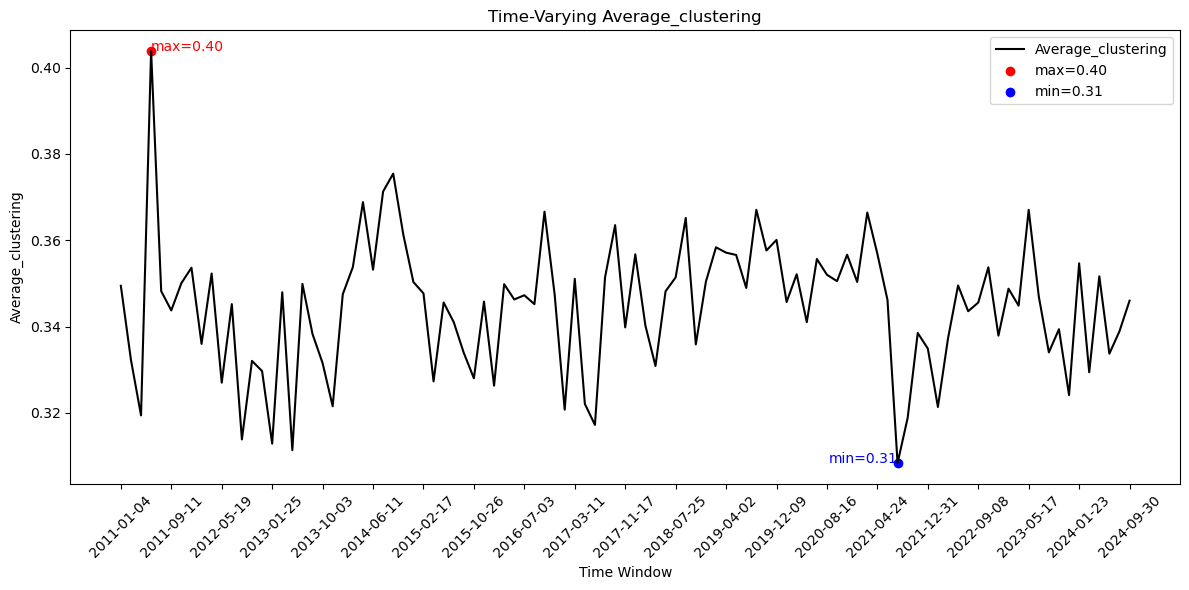

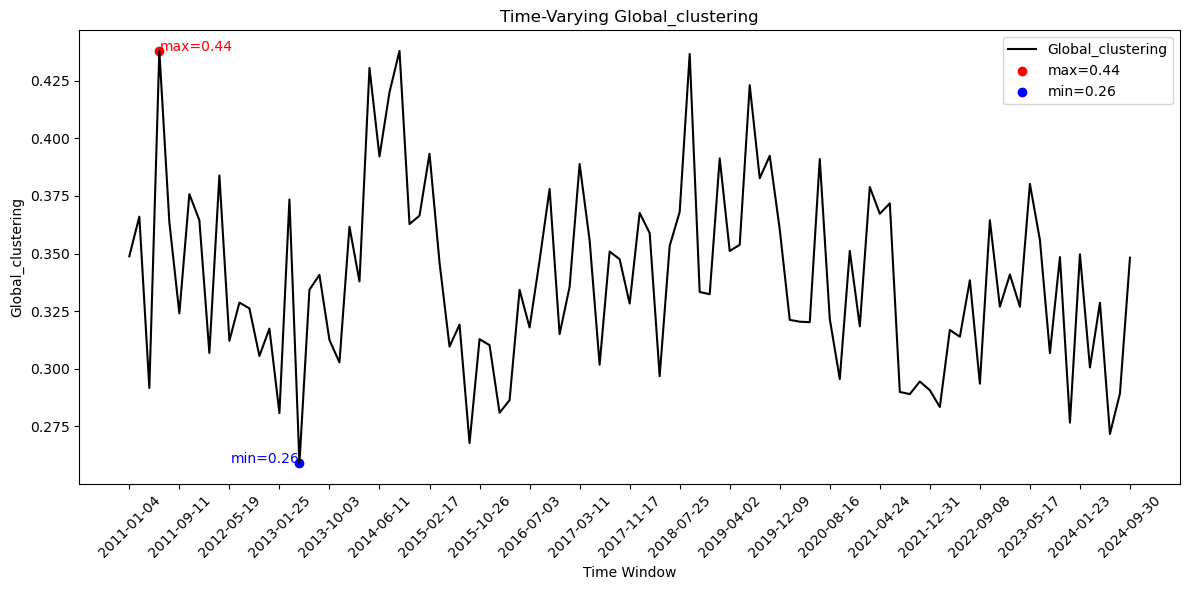

In [80]:
# 初始化结果存储
metrics_results = []

# 计算所有 PMFG 网络的特征
for idx, pmfg in enumerate(pmfg_networks):
    metrics = calculate_network_metrics(pmfg)
    metrics['time_window'] = idx + 1  # 添加时间窗口标识
    metrics_results.append(metrics)

# 转换为 DataFrame
metrics_df = pd.DataFrame(metrics_results)

# 保存结果到 Excel
metrics_df.to_excel('../result/network_metrics_results.xlsx', index=False)

for metric in ['average_clustering', 'global_clustering']:
    # 找到最大值和最小值
    max_value = metrics_df[metric].max()
    min_value = metrics_df[metric].min()
    max_index = metrics_df[metric].idxmax()
    min_index = metrics_df[metric].idxmin()
    
    # 绘制图表
    plt.figure(figsize=(12, 6))
    plt.plot(time_range, metrics_df[metric], marker="", label=metric.capitalize(), color='black')
    plt.scatter(time_range[max_index], max_value, color='red', label=f"max={max_value:.2f}")
    plt.scatter(time_range[min_index], min_value, color='blue', label=f"min={min_value:.2f}")
    plt.text(time_range[max_index], max_value, f"max={max_value:.2f}", color='red', ha='left', fontsize=10)
    plt.text(time_range[min_index], min_value, f"min={min_value:.2f}", color='blue', ha='right', fontsize=10)

    # 设置横坐标为时间
    plt.xticks(time_range[::5], rotation=45)  # 每隔 5 个时间窗口显示一个时间标签
    plt.xlabel('Time Window')
    plt.ylabel(metric.capitalize())
    plt.title(f'Time-Varying {metric.capitalize()}')
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(f'{metric}_time_varying_plot.png')
    plt.show()



In [70]:
# 初始化指标存储
network_efficiency = []  # 网络效率
network_robustness = []  # 鲁棒性
reciprocity = []  # 偏向性系数
modularity_scores = []  # 模块化

# 逐个时间窗口计算指标
for i in range(num_matrices):
    # 提取当前矩阵
    start_row = i * num_nodes
    end_row = (i + 1) * num_nodes
    matrix = data.iloc[start_row:end_row].to_numpy()

    # 构建加权有向图
    G = nx.from_numpy_array(matrix, create_using=nx.DiGraph())

    # 1. 网络效率（仅考虑可达节点对）
    efficiency = nx.global_efficiency(G.to_undirected())  # 全局效率
    network_efficiency.append(efficiency)

    # 2. 鲁棒性（节点删除后的连通性）
    original_size = len(max(nx.weakly_connected_components(G), key=len))
    G_removed = G.copy()
    G_removed.remove_node(0)  # 随机删除一个节点，测试鲁棒性
    reduced_size = len(max(nx.weakly_connected_components(G_removed), key=len))
    robustness = reduced_size / original_size  # 剩余最大连通分量比例
    network_robustness.append(robustness)

    # 3. 偏向性系数（双向边比例）
    reciprocal_edges = sum(1 for u, v in G.edges() if G.has_edge(v, u))  # 双向边
    reciprocity_score = reciprocal_edges / G.number_of_edges() if G.number_of_edges() > 0 else 0
    reciprocity.append(reciprocity_score)

    # 4. 模块化（社区结构）
    communities = nx.algorithms.community.greedy_modularity_communities(G.to_undirected())
    modularity = nx.algorithms.community.modularity(G.to_undirected(), communities)
    modularity_scores.append(modularity)

# 通用绘图函数
def plot_metric(time_range, metric_values, ylabel, title):
    max_value = max(metric_values)
    min_value = min(metric_values)
    max_index = metric_values.index(max_value)
    min_index = metric_values.index(min_value)

    plt.figure(figsize=(12, 6))
    plt.plot(time_range, metric_values, label=ylabel, color='black')
    plt.scatter(time_range[max_index], max_value, color='red', label=f"max={max_value:.2f}")
    plt.scatter(time_range[min_index], min_value, color='blue', label=f"min={min_value:.2f}")
    plt.text(time_range[max_index], max_value, f"max={max_value:.2f}", color='red', ha='left', fontsize=10)
    plt.text(time_range[min_index], min_value, f"min={min_value:.2f}", color='blue', ha='right', fontsize=10)
    
    # 设置横坐标为时间
    plt.xticks(rotation=45)
    plt.gca().set_xticks(time_range[::5])  
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

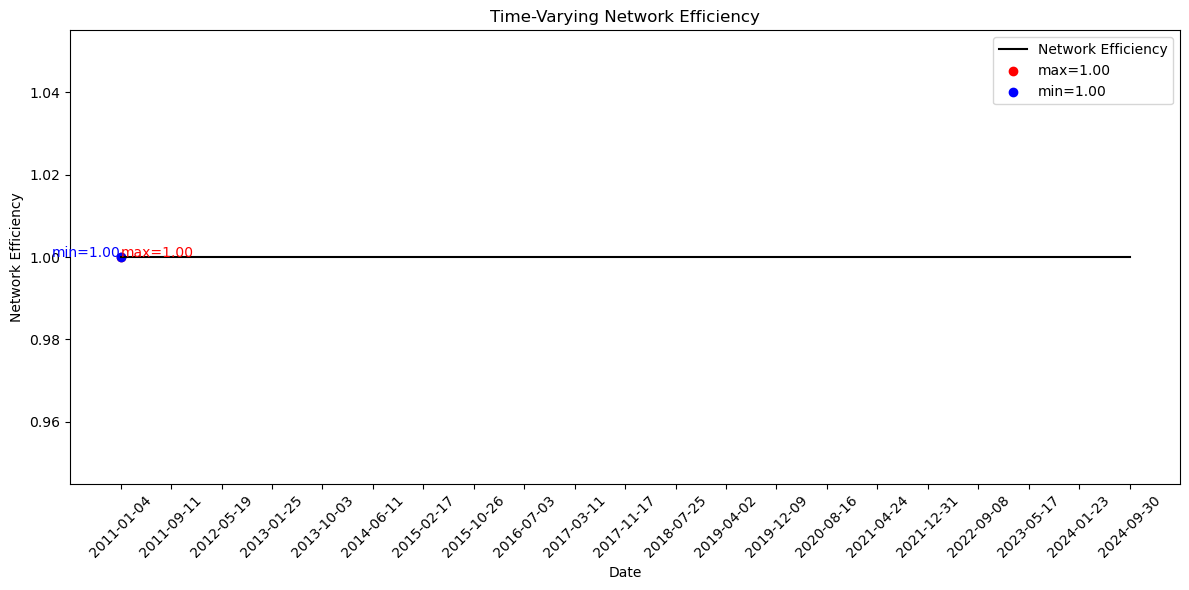

In [71]:
# 绘制动态网络效率
plot_metric(time_range, network_efficiency, "Network Efficiency", "Time-Varying Network Efficiency")

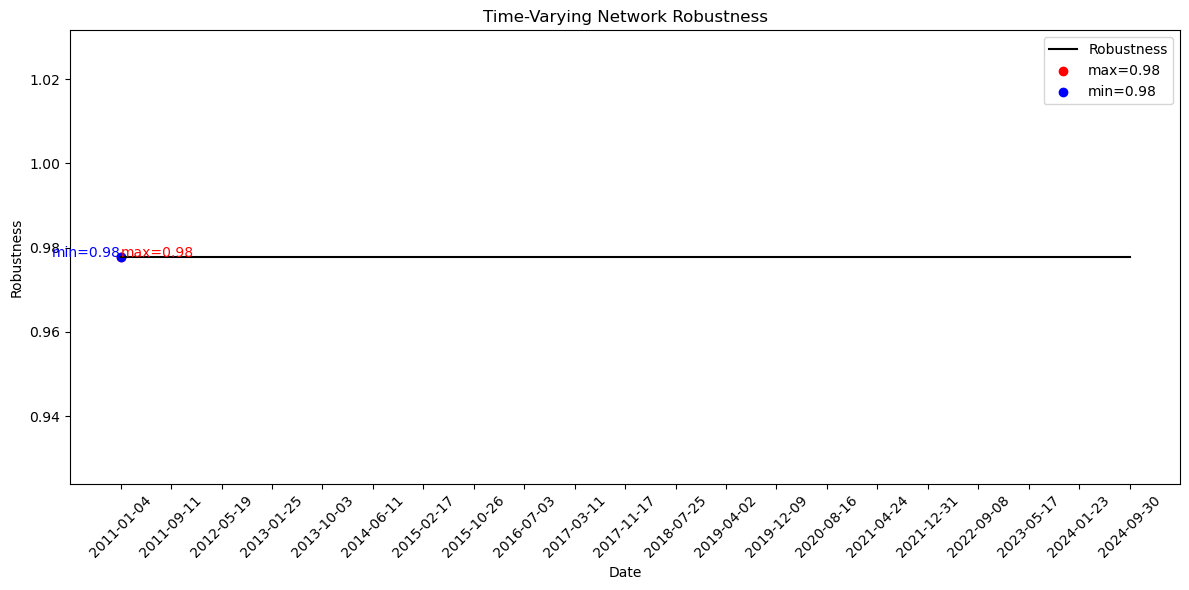

In [72]:
# 绘制鲁棒性
plot_metric(time_range, network_robustness, "Robustness", "Time-Varying Network Robustness")

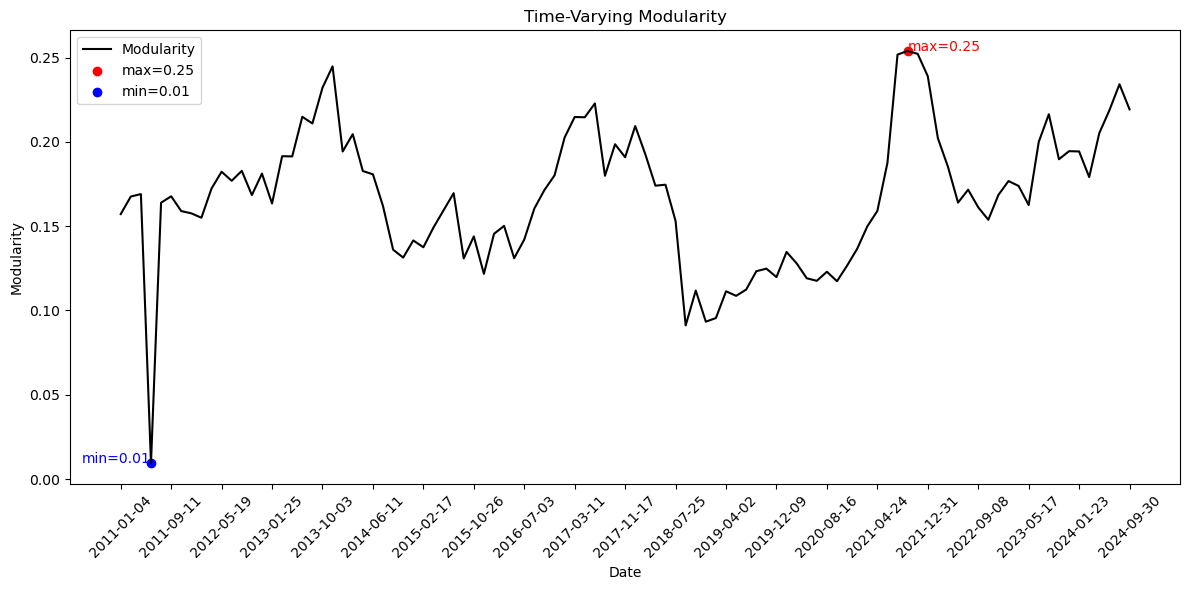

In [73]:
# 绘制模块化
plot_metric(time_range, modularity_scores, "Modularity", "Time-Varying Modularity")

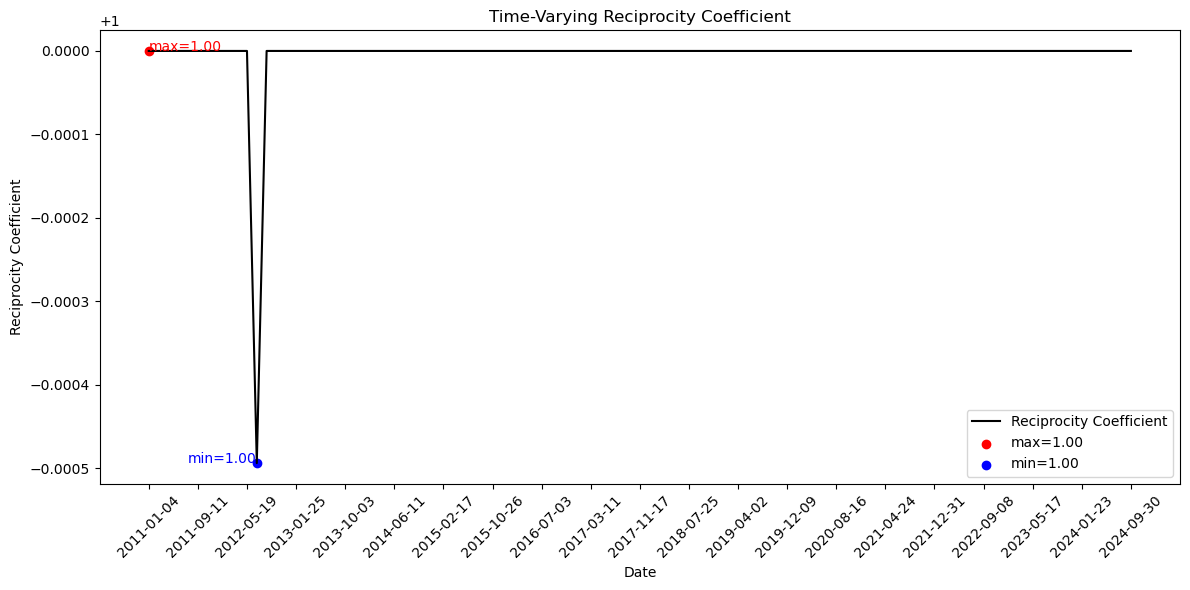

In [74]:
# 绘制偏向性系数
plot_metric(time_range, reciprocity, "Reciprocity Coefficient", "Time-Varying Reciprocity Coefficient")

### MST
- 最小生成树（MST）是一种稀疏图，它仅保留 𝑁−1条边（对于𝑁个节点的网络）。这种结构天然具有极低的聚类特性，因为生成树本质上不会形成三角形（闭合路径）。

In [93]:
# 读取 Excel 文件，加载所有工作表
file_path = '../data/dynamic_connectedness45.xlsx'  # 替换为实际路径
data = pd.read_excel(file_path, sheet_name=None)  # 加载为字典
print(data.keys())  # 查看工作表名称，结果是 dict_keys(['weight'])

data = data["dynamic_connectedness"]  

dict_keys(['dynamic_connectedness'])
